# Lab 4: Data Quality Assessment & Preprocessing


In [17]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

 ## 1.Load Dataset

In [18]:
df= pd.read_csv("Aramco.csv")
df.head(10)

,Date,Close,High,Low,Open,Volume
0,12/11/2019,22.352606,22.352606,22.352606,22.352606,38289394
1,12/12/2019,23.368637,24.575170,22.860623,24.575170,505692621
2,12/15/2019,23.749640,23.813142,23.368630,23.559135,98349281
3,12/16/2019,24.130653,24.194154,23.813145,23.813145,105973907
4,12/17/2019,23.971899,24.225905,23.813145,24.162403,142672245
5,12/18/2019,23.305134,23.876650,23.305134,23.813148,83822621
6,12/19/2019,22.543108,23.336880,22.543108,23.305128,108120197
7,12/22/2019,22.416105,22.670112,22.162099,22.606611,39709972
8,12/23/2019,22.606611,22.638361,22.384355,22.416106,35098090
9,12/24/2019,22.479609,22.670113,22.416106,22.638361,22184338


 ## 2.  Task 1: Data Quality Assessment
 ### 2.1 Check Data Types



In [19]:
df.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [20]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

The data type inspection shows that several columns are stored as object types, including date  values. While categorical features are expected to be objects, date values stored as objects indicate formatting issues. Identifying such inconsistencies is important before proceeding with deeper analysis

### 2.2 Check Data Missing Values


In [21]:
df.isna()


,Date,Close,High,Low,Open,Volume
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
1509,False,False,False,False,False,False
1510,False,False,False,False,False,False
1511,False,False,False,False,False,False
1512,False,False,False,False,False,False


In [22]:
df.isna().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

 The dataset dose not contain any missing value. All columns returned zero missing entries.

### 2.3 Chek Data Duplicates

In [23]:
df.duplicated().sum()

np.int64(0)

There are no dublicate rows in the dataset.

## 3.Task 2: Aplly one missing value strategy and explain why

In fact, this dataset does not contain missing values, but I will add missing values to apply this task.

In [24]:
df2 = df.copy()
df2.loc[0:5, 'Volume']=np.nan
df2.isna().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    6
dtype: int64

Now the Volume contains missing values.

In [25]:
df2.head(10)

,Date,Close,High,Low,Open,Volume
0,2019-12-11,22.352606,22.352606,22.352606,22.352606,NaN
1,2019-12-12,23.368637,24.575170,22.860623,24.575170,NaN
2,2019-12-15,23.749640,23.813142,23.368630,23.559135,NaN
3,2019-12-16,24.130653,24.194154,23.813145,23.813145,NaN
4,2019-12-17,23.971899,24.225905,23.813145,24.162403,NaN
5,2019-12-18,23.305134,23.876650,23.305134,23.813148,NaN
6,2019-12-19,22.543108,23.336880,22.543108,23.305128,108120197.0
7,2019-12-22,22.416105,22.670112,22.162099,22.606611,39709972.0
8,2019-12-23,22.606611,22.638361,22.384355,22.416106,35098090.0
9,2019-12-24,22.479609,22.670113,22.416106,22.638361,22184338.0


### 3.1 Strategy : Median Imputation

In [26]:
df['Volume'].describe()

count    1.514000e+03
mean     1.083187e+07
std      2.391855e+07
min      0.000000e+00
25%      4.466211e+06
50%      7.548395e+06
75%      1.247766e+07
max      6.562831e+08
Name: Volume, dtype: float64

In [29]:
df_median = df2.copy()
df_median['Volume'].fillna(df_median['Volume'].median(), inplace=True)
df_median.head(10)

C:\Users\she5o\AppData\Local\Temp\ipykernel_14368\1834838622.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_median['Volume'].fillna(df_median['Volume'].median(), inplace=True)


,Date,Close,High,Low,Open,Volume
0,2019-12-11,22.352606,22.352606,22.352606,22.352606,7504848.5
1,2019-12-12,23.368637,24.575170,22.860623,24.575170,7504848.5
2,2019-12-15,23.749640,23.813142,23.368630,23.559135,7504848.5
3,2019-12-16,24.130653,24.194154,23.813145,23.813145,7504848.5
4,2019-12-17,23.971899,24.225905,23.813145,24.162403,7504848.5
5,2019-12-18,23.305134,23.876650,23.305134,23.813148,7504848.5
6,2019-12-19,22.543108,23.336880,22.543108,23.305128,108120197.0
7,2019-12-22,22.416105,22.670112,22.162099,22.606611,39709972.0
8,2019-12-23,22.606611,22.638361,22.384355,22.416106,35098090.0
9,2019-12-24,22.479609,22.670113,22.416106,22.638361,22184338.0


The median strategy was used because the 'Volume' column contains extream values. Median is more robust to outliers than the mean.

### 4. Task 3: Handling Outliers


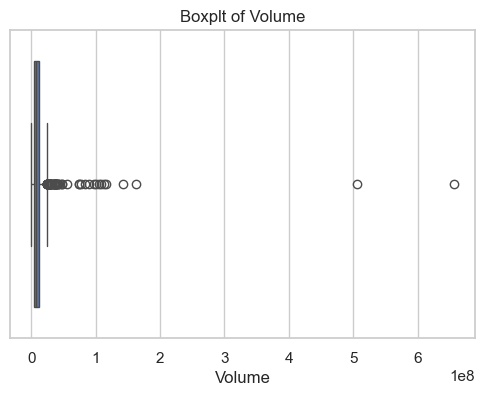

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Volume'])

plt.title('Boxplt of Volume')
plt.show()

###  4.1 Detect Outliers using IQR

In [31]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Volume'] < lower) | (df['Volume'] > upper)]
outliers.head(15)

,Date,Close,High,Low,Open,Volume
0,2019-12-11,22.352606,22.352606,22.352606,22.352606,38289394
1,2019-12-12,23.368637,24.575170,22.860623,24.575170,505692621
2,2019-12-15,23.749640,23.813142,23.368630,23.559135,98349281
3,2019-12-16,24.130653,24.194154,23.813145,23.813145,105973907
4,2019-12-17,23.971899,24.225905,23.813145,24.162403,142672245
5,2019-12-18,23.305134,23.876650,23.305134,23.813148,83822621
6,2019-12-19,22.543108,23.336880,22.543108,23.305128,108120197
7,2019-12-22,22.416105,22.670112,22.162099,22.606611,39709972
8,2019-12-23,22.606611,22.638361,22.384355,22.416106,35098090
17,2020-01-05,21.939846,22.225604,21.908095,22.225604,25239125


### 4.2 Removing outliers 

In [32]:
df_no_outliers = df[(df['Volume'] >= lower) & (df['Volume'] <= upper)]

print('df with outliers: ',df.shape)
print('df without outliers: ',df_no_outliers.shape)

df with outliers:  (1514, 6)
df without outliers:  (1436, 6)


### 4.3 Capping Outliers (Percentile Method)


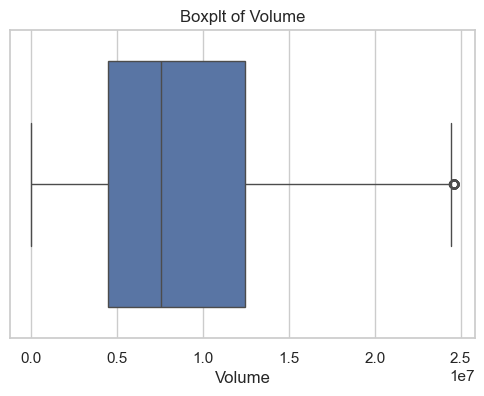

In [34]:
lower_cap = df['Volume'].quantile(0.05) 
upper_cap = df['Volume'].quantile(0.95) 

df_capped = df.copy()

df_capped['Volume'] = df_capped['Volume'].clip(lower_cap, upper_cap)
plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped['Volume'])

plt.title('Boxplt of Volume')
plt.show()


##  5. Task 4: Normalize numerical features using both Min-Max and Z-score.

### 5.1 Min-Max Normalization

In [42]:
df[['Volume','Open','High','Low','Close']].head()

,Volume,Open,High,Low,Close
0,38289394,22.352606,22.352606,22.352606,22.352606
1,505692621,24.575170,24.575170,22.860623,23.368637
2,98349281,23.559135,23.813142,23.368630,23.749640
3,105973907,23.813145,24.194154,23.813145,24.130653
4,142672245,24.162403,24.225905,23.813145,23.971899


In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Volume','Open','High','Low','Close']].copy()

df_scaled[['Volume','Open','High','Low','Close']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Volume,Open,High,Low,Close
0,0.058343,0.352072,0.300045,0.357521,0.329025
1,0.770540,0.502346,0.452242,0.392401,0.400165
2,0.149858,0.433649,0.400060,0.427281,0.426842
3,0.161476,0.450823,0.426151,0.457801,0.453520
4,0.217394,0.474438,0.428325,0.457801,0.442405


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.


### 5.2 Z-Score Normalization

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Volume','Open','High','Low','Close']].copy()

df_standardized[['Volume','Open','High','Low','Close']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Volume,Open,High,Low,Close
0,1.148339,-1.101095,-1.143526,-1.060088,-1.104889
1,20.696250,-0.281595,-0.330690,-0.870239,-0.728745
2,3.660186,-0.656225,-0.609379,-0.680393,-0.587695
3,3.979066,-0.562568,-0.470035,-0.514275,-0.446640
4,5.513877,-0.433790,-0.458423,-0.514275,-0.505413


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

##  6. Task 5: Apply PCA only if the numerical features show a correlation.

### 6.1 Check Correlation Before Applying PCA

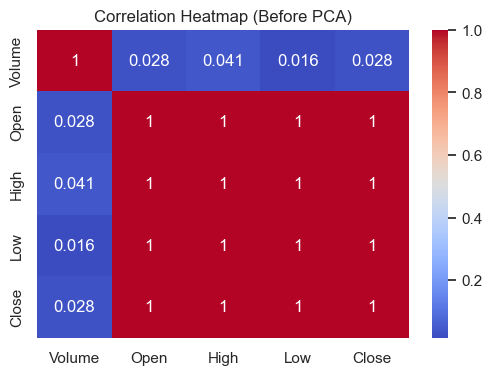

In [47]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['Volume','Open','High','Low','Close']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The correlation heatmap shows strong correlations between the price features (Open, High, Low, Close). Therefore, PCA can be applied to reduce dimensionality while preserving most of the information.

### 6.2 Data Reduction – Principal Component Analysis (PCA)

In [48]:
from sklearn.decomposition import PCA

X = df_standardized[['Volume','Open','High','Low','Close']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.79872515 0.19985097]


The first principal component explains about 79.9% of the variance, while the second explains about 20%. Together they capture almost all the information in the dataset.

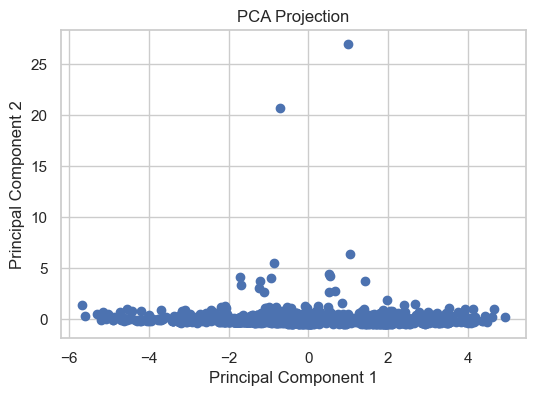

In [49]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The scatter plot shows the projection of the data onto the first two principal components. Most of the variance is captured along PC1, indicating it is the most informative direction in the data.